In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [28]:
diabetes = load_diabetes()
print("features:", diabetes.feature_names)
print("\nTarget: Disease progression after one year (co)")

features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target: Disease progression after one year (co)


In [29]:
df =  pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['progression'] = diabetes.target
print('shape:',df.shape)
df.head()

shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [30]:
print('target statistics:')
print(df['progression'].describe())


target statistics:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: progression, dtype: float64


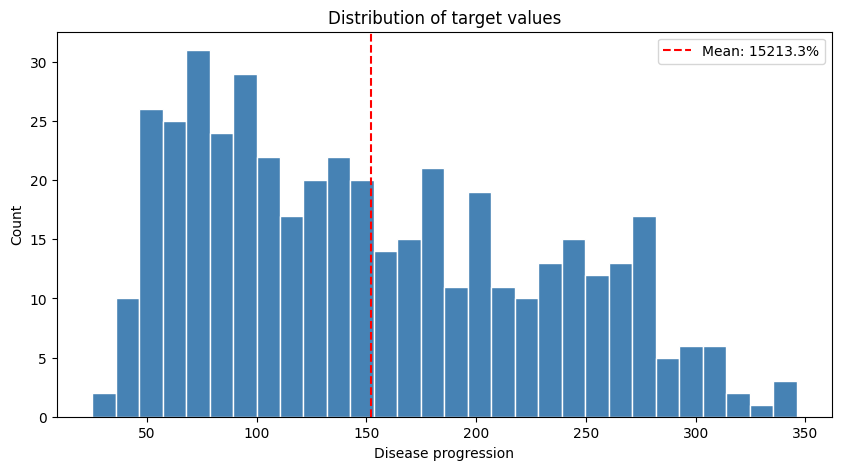

In [31]:
plt.figure(figsize=(10,5))
plt.hist(df['progression'], bins=30, color='steelblue',edgecolor='white')
plt.xlabel('Disease progression')
plt.ylabel('Count')
plt.title('Distribution of target values')
plt.axvline(df['progression'].mean(), color='red', linestyle='--', label=f"Mean: {df['progression'].mean():.1%}")
plt.legend()
plt.show()


In [32]:
X = df.drop('progression', axis=1)
y = df['progression']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print(f"Training: {len(X_train)}")
print(f"Testing: {len(X_test)}")

Training: 353
Testing: 89


In [33]:
#Train Linear Regression
data = load_diabetes()
X = data.data
y = data.target


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training:{len(X_train)}")
print(f"Testing:{len(y_test)}")

Training:353
Testing:89


In [35]:
model = LinearRegression()

In [36]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
y_pred = model.predict(X_test)
print(y_pred[:5])


[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872]


In [44]:
comparison = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": y_pred[:10]
})

# print(comparison.head(10))
compare10 = comparison.copy()
compare10["Error"] = compare10["Actual"] - compare10["Predicted"]
compare10

,Actual,Predicted,Error
0,219.0,139.547558,79.452442
1,70.0,179.517208,-109.517208
2,202.0,134.038756,67.961244
3,230.0,291.417029,-61.417029
4,111.0,123.789659,-12.789659
5,84.0,92.172347,-8.172347
6,242.0,258.232389,-16.232389
7,272.0,181.337321,90.662679
8,94.0,90.224113,3.775887
9,96.0,108.633759,-12.633759


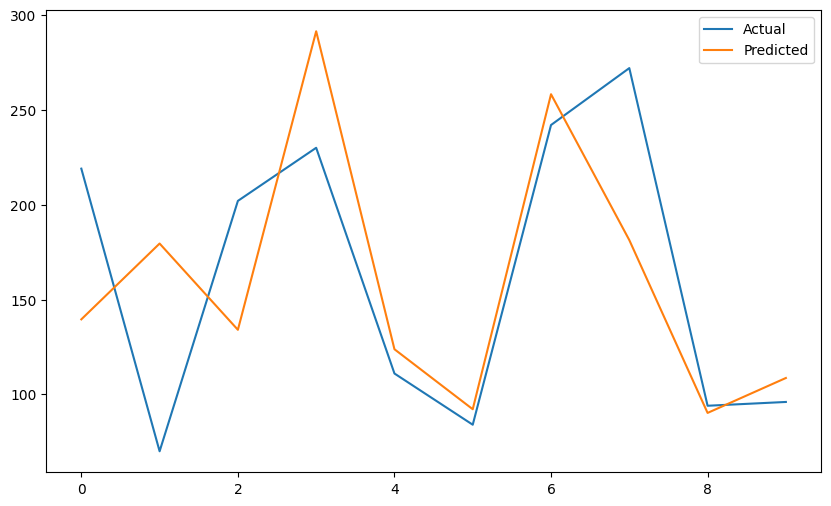

In [39]:
plt.figure(figsize=(10,6))
plt.plot(y_test[:10], label="Actual")
plt.plot(y_pred[:10], label="Predicted")
plt.legend()
plt.show()


In [43]:
compare20 = pd.DataFrame({
    "Actual": y_test[:20],
    "Predicted": y_pred[:20]
})
compare20["Error"] = compare20["Actual"] - compare20["Predicted"]
compare20

,Actual,Predicted,Error
0,219.0,139.547558,79.452442
1,70.0,179.517208,-109.517208
2,202.0,134.038756,67.961244
3,230.0,291.417029,-61.417029
4,111.0,123.789659,-12.789659
5,84.0,92.172347,-8.172347
6,242.0,258.232389,-16.232389
7,272.0,181.337321,90.662679
8,94.0,90.224113,3.775887
9,96.0,108.633759,-12.633759


In [45]:
print(r2_score(y_test, y_pred))

0.4526027629719196


In [46]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)


print("MAE:", mae)
print("MSE:", mse)


MAE: 42.79409467959994
MSE: 2900.193628493481


In [48]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
print("Model comparison:")
print(f"{'Model' : <25}{'MAE': <10}{'RMSE': <10}{'R2': <25}")
print('-'*50)
print(f"{'liner regression': <25}{mean_absolute_error(y_test, y_pred) :<10.2f}{np.sqrt(mean_squared_error(y_test, y_pred)):<10.2f}{r2_score(y_test, y_pred):<10.4f}")
print(f"{'Random Forest': <25}{mean_absolute_error(y_test, rf_y_pred) :<10.2f}{np.sqrt(mean_squared_error(y_test, rf_y_pred)):<10.2f}{r2_score(y_test, rf_y_pred):<10.4f}")


Model comparison:
Model                    MAE       RMSE      R2                       
--------------------------------------------------
liner regression         42.79     53.85     0.4526    
Random Forest            44.05     54.33     0.4428    


In [49]:
coef_df = pd.DataFrame({
    "Feature": diabetes.feature_names,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)
coef_df

,Feature,Coefficient
4,s1,-931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,-241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021


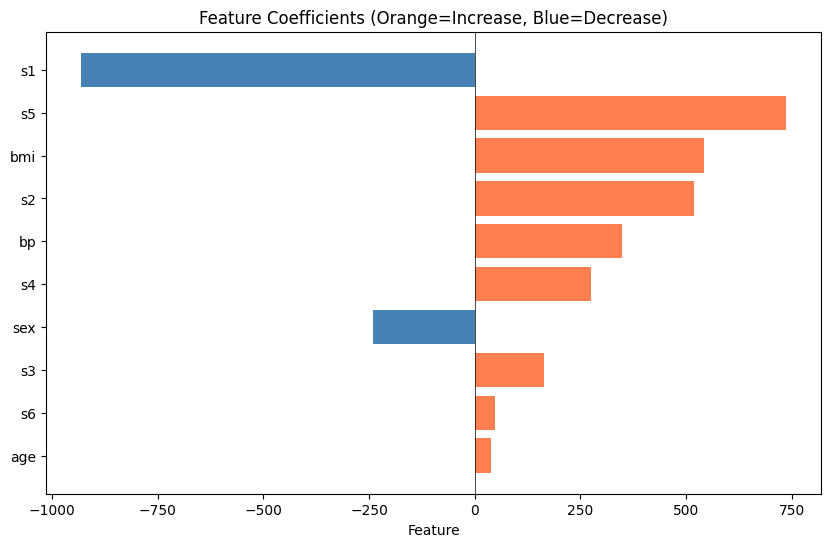

In [53]:
plt.figure(figsize=(10,6))
colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Feature')
plt.title('Feature Coefficients (Orange=Increase, Blue=Decrease)')
plt.axvline(x=0, color='black', linewidth='0.5')
plt.gca().invert_yaxis()#
plt.show()